# TimeXer + XCorr-Lag Exogenous — Notebook hoàn chỉnh

**Hướng EXOGENOUS (tự đảm nhiệm, thay nhánh cũ):** lọc/căn biến ngoại sinh theo
**tương quan phi tuyến + độ trễ** với mục tiêu, nhúng thẳng vào TimeXer.

* **Pha 1** — hồ sơ liên quan phi tuyến theo độ trễ bằng **distance correlation (dCor)**:
  tự khám phá biến ngoại sinh nào quan trọng + ở độ trễ nào, *không* feature thủ công,
  *không* lag chốt tay. Tính một lần offline trên train (chống rò rỉ).
* **Pha 2** — `XCorrLagExogenous`: căn lag nhân quả + **cổng liên quan học được**,
  khởi tạo theo prior dCor. **Nested baseline:** tắt cả hai ⇒ TimeXer gốc.
* **Ablation 2×2 × đa-seed:** {exo off/on} × {MSE / custom loss}.

> Chỉ cần sửa `DATA_ROOT`. Cần 4 file: `clean_hourly.csv`, `train.csv`, `val.csv`, `test.csv`
> (tùy chọn `loss_weights.npz` để bật cột custom loss).

In [12]:
# CELL 1 — (Colab) mount Drive + cài đặt
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass
!pip install torch scikit-learn --quiet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# CELL 2 — Import
import os, math, time, random, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

Device: cuda


In [19]:
# CELL 3 — Config  (TODO: chỉ sửa DATA_ROOT)
DATA_ROOT = '/content/drive/MyDrive/Time_Series_Group_1/Data/Processed/'
CLEAN_CSV = DATA_ROOT + 'clean_hourly.csv'

# Cửa sổ & mô hình (giữ nguyên TimeXer)
SEQ_LEN, LABEL_LEN, PRED_LEN, PATCH_LEN = 168, 48, 24, 24
D_MODEL, N_HEADS, E_LAYERS, D_FF = 512, 8, 2, 2048
DROPOUT, ACTIVATION, USE_NORM = 0.1, 'gelu', True

# Huấn luyện
BATCH_SIZE, LR, TRAIN_EPOCHS, PATIENCE = 32, 1e-4, 15, 5
TARGET = 'load'

# Hướng exogenous (Pha 1)
EXO_COLS = ['temp', 'humidity', 'pressure', 'wind_speed', 'clouds_all']  # kênh NGẪU NHIÊN
SEASON_PERIOD, LAG_MULT = 24, 1.0          # cửa sổ lag L = round(LAG_MULT*period)
MEASURE, DCOR_SUBSAMPLE = 'dcor', 3000     # 'dcor' | 'mi'
GATE_INIT = 'prior_centered'               # 'prior_centered' | 'relevance' | 'ones'

# Ablation
SEEDS = [42, 43, 44]                        # đa-seed BẮT BUỘC
LOSS_VARIANTS = ['mse', 'weighted']        # cột loss của lưới 2×2
LOSS_WEIGHTS_PATH = DATA_ROOT + 'loss_weights.npz'
LOSS_WEIGHTS_KEY  = 'w_invvar'             # biến thể easy_demua (nghịch phương sai)
LOSS_AR_ORDER = 2                          # bậc AR (khớp cấu trúc AR(2) đã nhận diện)
COND_MAX = 150                             # chặn số điều kiện của Σ (shrinkage)

In [15]:
# CELL 4 — Time features
def time_features(df_stamp):
    d = pd.DatetimeIndex(pd.to_datetime(df_stamp['date'].values))
    f = [d.hour/23.0-0.5, d.dayofweek/6.0-0.5, (d.day-1)/30.0-0.5, (d.dayofyear-1)/365.0-0.5]
    return np.vstack(f).T  # [T,4]

In [16]:
# CELL 5 — Dataset (đọc train/val/test.csv; scaler fit CHỈ trên train)
class Dataset_Electricity(Dataset):
    def __init__(self, root, flag, scaler=None):
        self.flag, self.scaler = flag, scaler
        fmap = {'train':'train.csv','val':'val.csv','test':'test.csv'}
        df = pd.read_csv(os.path.join(root, fmap[flag]))
        if 'time' in df.columns: df = df.rename(columns={'time':'date'})
        for c in df.columns:
            if c != 'date':
                df[c] = pd.to_numeric(df[c].astype(str).str.replace(',',''), errors='coerce')
        df['date'] = pd.to_datetime(df['date'], utc=True)
        df = df.sort_values('date').reset_index(drop=True)
        feat = [c for c in df.columns if c not in ['date', TARGET]]
        df = df[['date'] + feat + [TARGET]]          # thứ tự: features + [target]
        dd = df.iloc[:, 1:]
        if flag == 'train':
            self.scaler = StandardScaler().fit(dd.values)
        assert self.scaler is not None, 'val/test cần scaler từ train'
        data = self.scaler.transform(dd.values)
        self.data_stamp = time_features(df[['date']])
        self.data_x, self.data_y = data, data[:, -1:]
    def __len__(self): return len(self.data_x) - SEQ_LEN - PRED_LEN + 1
    def __getitem__(self, i):
        s,e = i, i+SEQ_LEN; rb = e-LABEL_LEN; re = rb+LABEL_LEN+PRED_LEN
        return (torch.FloatTensor(self.data_x[s:e]),  torch.FloatTensor(self.data_y[rb:re]),
                torch.FloatTensor(self.data_stamp[s:e]), torch.FloatTensor(self.data_stamp[rb:re]))

def build_datasets():
    tr = Dataset_Electricity(DATA_ROOT, 'train')
    va = Dataset_Electricity(DATA_ROOT, 'val',  tr.scaler)
    te = Dataset_Electricity(DATA_ROOT, 'test', tr.scaler)
    return tr, va, te

def build_loaders(dss, seed):
    tr, va, te = dss
    g = torch.Generator(); g.manual_seed(seed)
    return {'train': DataLoader(tr, BATCH_SIZE, shuffle=True, drop_last=True, generator=g, num_workers=2),
            'val':   DataLoader(va, BATCH_SIZE, shuffle=False, num_workers=2),
            'test':  DataLoader(te, BATCH_SIZE, shuffle=False, num_workers=2)}

## Pha 1 — Hồ sơ liên quan phi tuyến theo độ trễ (dCor)

$R_j(\tau) = \mathrm{dCor}\big(\tilde x^{(j)}_{t-\tau},\ \tilde y_t\big)$ trên phần dư khử mùa vụ
(giờ-trong-tuần), chỉ trên train. dCor$=0 \iff$ độc lập ⇒ bắt cả phụ thuộc **phi tuyến**
(quan hệ nhiệt độ–tải hình U) mà Pearson bỏ sót. $\tau_j^*=\arg\max_\tau R_j(\tau)$.

In [17]:
# CELL 6 — Pha 1: hàm
def _how(ts):
    d = pd.DatetimeIndex(ts); return (d.dayofweek.values*24 + d.hour.values).astype(int)
def _deseason(v, sidx):
    nb = int(sidx.max())+1
    clim = np.array([v[sidx==b].mean() if (sidx==b).any() else 0. for b in range(nb)])
    return v - clim[sidx]
def _dc(d): return d - d.mean(0,keepdims=True) - d.mean(1,keepdims=True) + d.mean()
def _dcor_fromB(x, B, dvy):
    A = _dc(np.abs(x[:,None]-x[None,:])); dcov2 = (A*B).mean(); dvx = np.sqrt((A*A).mean())
    return float(np.sqrt(max(dcov2,0))/(np.sqrt(dvx*dvy)+1e-12))
def _mi(x, y):
    from sklearn.feature_selection import mutual_info_regression
    return float(mutual_info_regression(x[:,None], y, random_state=0)[0])

def build_exo_profile(clean_csv, train_end, exo_cols, period=24, lag_mult=1.0,
                      measure='dcor', subsample=3000, seed=0):
    rng = np.random.default_rng(seed)
    df = pd.read_csv(clean_csv, parse_dates=['time']).sort_values('time')
    df = df[df['time'] <= pd.Timestamp(train_end)].reset_index(drop=True)
    sidx = _how(df['time']); L = int(round(lag_mult*period))
    y = _deseason(df[TARGET].values.astype(float), sidx)
    xr = {c:_deseason(df[c].values.astype(float), sidx) for c in exo_cols}
    n = len(y); m = min(subsample, n-L); idx = rng.choice(np.arange(L,n), m, replace=False)
    ys = y[idx]
    if measure == 'dcor':
        B = _dc(np.abs(ys[:,None]-ys[None,:])); dvy = np.sqrt((B*B).mean())
    lags = np.arange(L+1); R = np.zeros((len(exo_cols), L+1))
    for j,c in enumerate(exo_cols):
        for tau in lags:
            xs = xr[c][idx-tau]
            R[j,tau] = _dcor_fromB(xs, B, dvy) if measure=='dcor' else _mi(xs, ys)
    ts = R.argmax(1).astype(int)
    return dict(names=list(exo_cols), lags=lags, R=R, tau_star=ts,
                R_star=R[np.arange(len(exo_cols)), ts], measure=measure)

def col_indices(csv, exo_cols):
    cols = [c for c in pd.read_csv(csv, nrows=0).columns if c not in ('time','date')]
    order = [c for c in cols if c != TARGET] + [TARGET]
    return {c:order.index(c) for c in exo_cols}, order

train_end=2017-10-19 14:00:00+00:00 | n_vars=16 | measure=dcor | L=24

kênh           tau*       R*     R(0)
temp             23   0.1721   0.1670
humidity         16   0.0670   0.0560
pressure         15   0.0634   0.0577
wind_speed       20   0.0942   0.0653
clouds_all       22   0.0527   0.0384


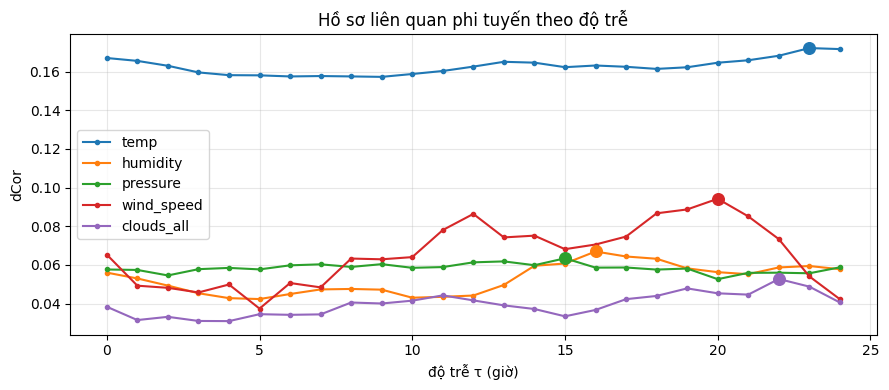

In [20]:
# CELL 7 — Pha 1: chạy + hồ sơ prior
train_end = pd.read_csv(DATA_ROOT+'train.csv', usecols=['time'])['time'].max()
profile = build_exo_profile(CLEAN_CSV, train_end, EXO_COLS, SEASON_PERIOD,
                            LAG_MULT, MEASURE, DCOR_SUBSAMPLE)
idx_map, order = col_indices(DATA_ROOT+'train.csv', EXO_COLS)
N_VARS = len(order)
print(f'train_end={train_end} | n_vars={N_VARS} | measure={MEASURE} | L={profile["lags"][-1]}\n')
print(f'{"kênh":<13}{"tau*":>6}{"R*":>9}{"R(0)":>9}')
for j,c in enumerate(profile['names']):
    print(f'{c:<13}{profile["tau_star"][j]:>6}{profile["R_star"][j]:>9.4f}{profile["R"][j,0]:>9.4f}')

# Biểu đồ hồ sơ dCor theo độ trễ
plt.figure(figsize=(9,4))
for j,c in enumerate(profile['names']):
    plt.plot(profile['lags'], profile['R'][j], marker='o', ms=3, label=c)
    plt.scatter([profile['tau_star'][j]],[profile['R_star'][j]], s=70, zorder=5)
plt.xlabel('độ trễ τ (giờ)'); plt.ylabel('dCor'); plt.title('Hồ sơ liên quan phi tuyến theo độ trễ')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Pha 2 — `XCorrLagExogenous` (căn lag + cổng liên quan học được)

Căn lag nhân quả theo $\tau_j^*$ (phép Linear$(T\!\to\!d)$ dùng chung cho mọi biến nên
không tự học được dịch pha riêng); cổng $g_j=\sigma(\theta_j)$ học được, khởi tạo theo prior.
Chỉ tác động kênh ngoại sinh; load/lịch/Fourier giữ nguyên.
**Nested:** `use_lag=False, use_gate=False` ⇒ identity ⇒ baseline gốc.

In [21]:
# CELL 8 — Pha 2: module
def _logit(p, eps=1e-4): p = p.clamp(eps,1-eps); return torch.log(p/(1-p))

class XCorrLagExogenous(nn.Module):
    def __init__(self, exo_idx, tau_star, R, n_vars, use_lag=True, use_gate=True,
                 learnable_gate=True, gate_init='prior_centered', center_spread=2.0):
        super().__init__()
        self.n_vars, self.use_lag, self.use_gate = n_vars, use_lag, use_gate
        self.register_buffer('exo_idx', torch.as_tensor(exo_idx, dtype=torch.long))
        self.register_buffer('tau_star', torch.as_tensor(tau_star, dtype=torch.long))
        R = torch.as_tensor(R, dtype=torch.float32); self.register_buffer('R', R)
        if   gate_init=='relevance': init = _logit(R)
        elif gate_init=='ones':      init = _logit(torch.ones_like(R)*0.999)
        elif gate_init=='prior_centered':
            z = (R-R.mean())/(R.std()+1e-6)
            g0 = (0.5+0.5*torch.tanh(z/center_spread)).clamp(0.1,0.9); init = _logit(g0)
        else: raise ValueError(gate_init)
        if use_gate:
            if learnable_gate: self.gate_logit = nn.Parameter(init.clone())
            else: self.register_buffer('gate_logit', init.clone())
    @staticmethod
    def from_profile(p, idx_map, n_vars, **kw):
        return XCorrLagExogenous([idx_map[c] for c in p['names']],
            [int(t) for t in p['tau_star']], [float(r) for r in p['R_star']], n_vars, **kw)
    def gates(self): return torch.sigmoid(self.gate_logit) if self.use_gate else None
    def forward(self, x):
        B,T,V = x.shape; cols = [x[:,:,v] for v in range(V)]
        if self.use_lag:
            for k,c in enumerate(self.exo_idx.tolist()):
                tau = int(self.tau_star[k])
                if tau>0:
                    col = cols[c]; cols[c] = torch.cat([col[:,:1].expand(B,tau), col[:,:T-tau]], 1)
        out = torch.stack(cols, -1)
        if self.use_gate:
            g = torch.sigmoid(self.gate_logit)
            gf = out.new_ones(V).scatter(0, self.exo_idx, g); out = out*gf.view(1,1,V)
        return out

# kiểm thử nhanh
_m = XCorrLagExogenous.from_profile(profile, idx_map, N_VARS, use_lag=False, use_gate=False)
assert _m(torch.randn(2,SEQ_LEN,N_VARS)).allclose(torch.randn(2,SEQ_LEN,N_VARS)) is False  # khác input ngẫu nhiên khác
print('nested-baseline identity:', _m(torch.ones(2,SEQ_LEN,N_VARS)).equal(torch.ones(2,SEQ_LEN,N_VARS)))

nested-baseline identity: True


## Kiến trúc TimeXer (khối gốc) + tích hợp XCorr-Lag

In [22]:
# CELL 9 — TimeXer blocks
class PositionalEmbedding(nn.Module):
    def __init__(self, d, ml=5000):
        super().__init__(); pe=torch.zeros(ml,d).float(); pos=torch.arange(0,ml).float().unsqueeze(1)
        dt=(torch.arange(0,d,2).float()*-(math.log(10000.)/d)).exp()
        pe[:,0::2]=torch.sin(pos*dt); pe[:,1::2]=torch.cos(pos*dt); self.register_buffer('pe',pe.unsqueeze(0))
    def forward(self,x): return self.pe[:,:x.size(1)]
class DataEmbedding_inverted(nn.Module):
    def __init__(self,c,d,dr=0.1): super().__init__(); self.ve=nn.Linear(c,d); self.dr=nn.Dropout(dr)
    def forward(self,x,xm):
        if xm is not None: x=torch.cat([x,xm],-1)
        return self.dr(self.ve(x.permute(0,2,1)))
class EnEmbedding(nn.Module):
    def __init__(self,nv,d,pl,dr):
        super().__init__(); self.pl=pl; self.ve=nn.Linear(pl,d,bias=False)
        self.glb=nn.Parameter(torch.randn(1,nv,1,d)); self.pe=PositionalEmbedding(d); self.dr=nn.Dropout(dr)
    def forward(self,x):
        B,nv=x.shape[0],x.shape[1]; glb=self.glb.repeat(B,1,1,1)
        x=x.unfold(-1,self.pl,self.pl); x=x.reshape(B*nv,x.shape[2],x.shape[3])
        x=self.ve(x)+self.pe(x); x=x.reshape(B,nv,x.shape[-2],x.shape[-1])
        x=torch.cat([x,glb],2); x=x.reshape(B*nv,x.shape[2],x.shape[3]); return self.dr(x),nv
class FullAttention(nn.Module):
    def __init__(self,ad=0.1): super().__init__(); self.dr=nn.Dropout(ad)
    def forward(self,q,k,v,m=None):
        B,L,H,E=q.shape; sc=1./math.sqrt(E)
        s=torch.einsum('blhe,bshe->bhls',q,k)*sc; A=self.dr(torch.softmax(s,-1))
        return torch.einsum('bhls,bshd->blhd',A,v).contiguous(),A
class AttentionLayer(nn.Module):
    def __init__(self,att,d,h):
        super().__init__(); dk=d//h; self.att=att
        self.q=nn.Linear(d,dk*h); self.k=nn.Linear(d,dk*h); self.v=nn.Linear(d,dk*h); self.o=nn.Linear(dk*h,d); self.h=h
    def forward(self,q,k,v,m=None):
        B,L,_=q.shape; _,S,_=k.shape; H=self.h
        Q=self.q(q).view(B,L,H,-1); K=self.k(k).view(B,S,H,-1); V=self.v(v).view(B,S,H,-1)
        o,a=self.att(Q,K,V,m); return self.o(o.view(B,L,-1)),a
class EncoderLayer(nn.Module):
    def __init__(self,sa,ca,d,dff=None,dr=0.1,act='gelu'):
        super().__init__(); dff=dff or 4*d; self.sa=sa; self.ca=ca
        self.c1=nn.Conv1d(d,dff,1); self.c2=nn.Conv1d(dff,d,1)
        self.n1=nn.LayerNorm(d); self.n2=nn.LayerNorm(d); self.n3=nn.LayerNorm(d)
        self.dr=nn.Dropout(dr); self.act=F.gelu if act=='gelu' else F.relu
    def forward(self,x,cross):
        nx,_=self.sa(x,x,x); x=self.n1(x+self.dr(nx))
        nx,_=self.ca(x,cross,cross); y=self.n2(x+self.dr(nx))
        y2=self.dr(self.act(self.c1(y.transpose(-1,1)))); y2=self.dr(self.c2(y2).transpose(-1,1))
        return self.n3(y+y2)
class Encoder(nn.Module):
    def __init__(self,layers,norm=None): super().__init__(); self.layers=nn.ModuleList(layers); self.norm=norm
    def forward(self,x,cross):
        for l in self.layers: x=l(x,cross)
        return self.norm(x) if self.norm is not None else x
class FlattenHead(nn.Module):
    def __init__(self,nv,nf,tw,dr=0):
        super().__init__(); self.fl=nn.Flatten(start_dim=-2); self.lin=nn.Linear(nf,tw); self.dr=nn.Dropout(dr)
    def forward(self,x): return self.dr(self.lin(self.fl(x)))

In [23]:
# CELL 10 — TimeXer tích hợp XCorr-Lag
class TimeXer(nn.Module):
    def __init__(self, profile, idx_map, n_vars, use_xcorr_lag, use_xcorr_gate, gate_init=GATE_INIT):
        super().__init__()
        self.n_vars = n_vars
        self.xcorr_exo = XCorrLagExogenous.from_profile(
            profile, idx_map, n_vars, use_lag=use_xcorr_lag, use_gate=use_xcorr_gate, gate_init=gate_init)
        self.en_embedding = EnEmbedding(1, D_MODEL, PATCH_LEN, DROPOUT)
        self.ex_embedding = DataEmbedding_inverted(SEQ_LEN, D_MODEL, DROPOUT)
        npn = SEQ_LEN//PATCH_LEN + 1
        self.encoder = Encoder([EncoderLayer(
            AttentionLayer(FullAttention(DROPOUT), D_MODEL, N_HEADS),
            AttentionLayer(FullAttention(DROPOUT), D_MODEL, N_HEADS),
            D_MODEL, D_FF, DROPOUT, ACTIVATION) for _ in range(E_LAYERS)], nn.LayerNorm(D_MODEL))
        self.head = FlattenHead(1, npn*D_MODEL, PRED_LEN, DROPOUT)
    def forward(self, x_enc, x_mark_enc):
        B = x_enc.shape[0]
        if USE_NORM:
            mean = x_enc.mean(1,keepdim=True).detach(); x_enc = x_enc-mean
            std  = torch.sqrt(torch.var(x_enc,1,keepdim=True,unbiased=False)+1e-5).detach(); x_enc = x_enc/std
        x_exo = self.xcorr_exo(x_enc)                       # <-- XCorr-Lag exogenous
        ex_out = self.ex_embedding(x_exo, x_mark_enc)
        x_endo = x_enc[:,:,-1:].permute(0,2,1)
        en_out, nv = self.en_embedding(x_endo)
        enc = self.encoder(en_out, ex_out.repeat_interleave(nv,0)).reshape(B,nv,-1,D_MODEL)
        out = self.head(enc[:,0,:,:])
        if USE_NORM: out = out*std[:,0,-1:] + mean[:,0,-1:]
        return out.unsqueeze(-1)

# sanity shape
set_seed(0)
_dss = build_datasets(); _ld = build_loaders(_dss, 0)
_x,_y,_xm,_ = next(iter(_ld['train']))
_mod = TimeXer(profile, idx_map, N_VARS, True, True).to(DEVICE)
with torch.no_grad(): _o = _mod(_x.to(DEVICE), _xm.to(DEVICE))
print('output shape:', tuple(_o.shape), '(mong đợi [B,24,1])')
del _mod, _ld

output shape: (32, 24, 1) (mong đợi [B,24,1])


## Pha 0 — Trọng số loss (tự suy từ train, tự chứa)

Tái dựng thiết kế nhánh loss **không cần file ngoài**: từ phần dư `load` khử mùa vụ trên
train, ước lượng AR$(p)$ (Yule–Walker) → biểu diễn MA$(\infty)$ $\{\psi_k\}$ → hiệp phương sai
sai số dự báo $h$-bước $\Sigma_\psi[i,j]=\sigma_\varepsilon^2\sum_{k}\psi_k\psi_{k+|i-j|}$.

* `w_invvar` $=1/\mathrm{diag}(\Sigma_\psi)$ — nghịch phương sai (biến thể `easy_demua`,
  **giảm đơn điệu** theo $h$ vì phương sai sai số tăng theo $h$).
* `W_invvar` $=\mathrm{shrink}(\Sigma_\psi)^{-1}$ — ma trận chính xác, **shrinkage đường chéo**
  để số điều kiện $\le$ `COND_MAX` (chống sụp gradient của `CorrStructLoss`).

Nếu có `loss_weights.npz` thật của bạn, nó **được ưu tiên**; thiếu thì dùng bản tự suy này.

AR(2) phi=[ 1.306 -0.358]  sig2=533547.10
cond(Σ): raw=1192 → shrink(α=0.08)=149
w_invvar (giảm đơn điệu?): [7.186 2.655 1.588 1.16  0.939 0.808 0.723 0.664 0.622 0.59  0.566 0.548
 0.533 0.521 0.512 0.504 0.498 0.493 0.489 0.485 0.482 0.48  0.478 0.476]


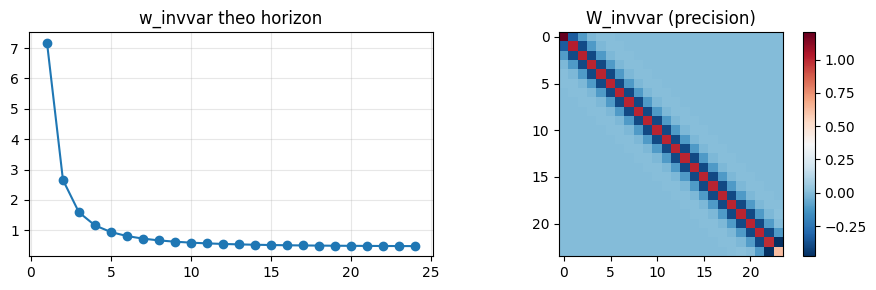

In [24]:
# CELL — Pha 0: suy trọng số loss từ train
def _autocov(x, maxlag):
    x = x - x.mean(); n = len(x)
    return np.array([ (x[:n-k]*x[k:]).sum()/n for k in range(maxlag+1) ])

def _ar_yule_walker(x, p):
    r = _autocov(x, p)
    R = np.array([[r[abs(i-j)] for j in range(p)] for i in range(p)])
    phi = np.linalg.solve(R + 1e-8*np.eye(p), r[1:p+1])
    sig2 = r[0] - phi @ r[1:p+1]
    return phi, max(sig2, 1e-8)

def _ma_psi(phi, H):
    p = len(phi); psi = np.zeros(H); psi[0] = 1.0
    for k in range(1, H):
        psi[k] = sum(phi[i]*psi[k-1-i] for i in range(min(p, k)))
    return psi

def _err_cov(psi, sig2, H):
    S = np.zeros((H, H))
    for a in range(H):
        for b in range(H):
            d = abs(a-b); m = min(a, b)
            S[a, b] = sig2 * sum(psi[k]*psi[k+d] for k in range(m+1))
    return S

def _shrink_to_cond(S, cond_max):
    tgt = (np.trace(S)/S.shape[0]) * np.eye(S.shape[0])
    for a in np.linspace(0, 1, 101):
        Sh = (1-a)*S + a*tgt
        if np.linalg.cond(Sh) <= cond_max:
            return Sh, float(a)
    return tgt, 1.0

def build_loss_prior(clean_csv, train_end, H, ar_order, cond_max):
    df = pd.read_csv(clean_csv, parse_dates=['time']).sort_values('time')
    df = df[df['time'] <= pd.Timestamp(train_end)].reset_index(drop=True)
    res = _deseason(df[TARGET].values.astype(float), _how(df['time']))     # dùng lại Pha 1
    phi, sig2 = _ar_yule_walker(res, ar_order)
    psi = _ma_psi(phi, H)
    Sig = _err_cov(psi, sig2, H)
    var_h = np.diag(Sig).copy()
    w_invvar = (1.0/var_h); w_invvar = w_invvar/ w_invvar.mean()           # giảm đơn điệu
    Sig_sh, alpha = _shrink_to_cond(Sig, cond_max)
    W = np.linalg.inv(Sig_sh); W = W/(np.trace(W)/H)                       # chuẩn hóa thang
    return dict(w_invvar=w_invvar.astype(np.float32),
                W_invvar=W.astype(np.float32),
                phi=phi, sig2=sig2, alpha=alpha,
                cond_raw=float(np.linalg.cond(Sig)), cond_sh=float(np.linalg.cond(Sig_sh)))

LOSS_PRIOR = build_loss_prior(CLEAN_CSV, train_end, PRED_LEN, LOSS_AR_ORDER, COND_MAX)
print(f'AR({LOSS_AR_ORDER}) phi={np.round(LOSS_PRIOR["phi"],3)}  sig2={LOSS_PRIOR["sig2"]:.2f}')
print(f'cond(Σ): raw={LOSS_PRIOR["cond_raw"]:.0f} → shrink(α={LOSS_PRIOR["alpha"]:.2f})={LOSS_PRIOR["cond_sh"]:.0f}')
print('w_invvar (giảm đơn điệu?):', np.round(LOSS_PRIOR['w_invvar'],3))

plt.figure(figsize=(9,3))
plt.subplot(1,2,1); plt.plot(range(1,PRED_LEN+1), LOSS_PRIOR['w_invvar'],'o-'); plt.title('w_invvar theo horizon'); plt.grid(alpha=.3)
plt.subplot(1,2,2); plt.imshow(LOSS_PRIOR['W_invvar'],cmap='RdBu_r'); plt.title('W_invvar (precision)'); plt.colorbar()
plt.tight_layout(); plt.show()

## Hàm mất mát — MSE và custom (nhánh loss)

`WeightedMSELoss` chuẩn hóa để trọng số đều ⇒ đúng MSE (nested). Nạp trọng số per-horizon
từ `loss_weights.npz[key]` (biến thể `easy_demua` = nghịch phương sai). Thiếu file ⇒ tạm dùng
trọng số đều (cột custom = MSE) kèm cảnh báo.

In [25]:
# CELL — Loss: MSE / weighted (easy_demua) / corr (CorrStruct)
class WeightedMSELoss(nn.Module):
    def __init__(self, w):
        super().__init__(); self.register_buffer('w', w / w.mean())     # w đều → MSE
    def forward(self, pred, true):
        return ((pred-true).pow(2).squeeze(-1) * self.w.view(1,-1)).mean()

class CorrStructLoss(nn.Module):
    """L = mean_b e_b^T W e_b / H ; W=I → MSE. W từ precision đã shrink."""
    def __init__(self, W):
        super().__init__(); self.register_buffer('W', W)
    def forward(self, pred, true):
        e = (pred-true).squeeze(-1)                                       # [B,H]
        return torch.einsum('bi,ij,bj->b', e, self.W, e).mean() / e.shape[1]

def _load_prior(key):
    # ưu tiên file thật của bạn; thiếu thì dùng bản tự suy (Pha 0)
    if os.path.exists(LOSS_WEIGHTS_PATH):
        arr = np.load(LOSS_WEIGHTS_PATH)
        if key in arr: return torch.tensor(arr[key], dtype=torch.float32)
    return torch.tensor(LOSS_PRIOR[key], dtype=torch.float32)

def make_loss(name):
    if name == 'mse':      return nn.MSELoss()
    if name == 'weighted':
        w = _load_prior(LOSS_WEIGHTS_KEY); assert w.numel()==PRED_LEN
        return WeightedMSELoss(w)
    if name == 'corr':
        W = _load_prior('W_invvar'); assert W.shape==(PRED_LEN,PRED_LEN)
        return CorrStructLoss(W)
    raise ValueError(name)

In [26]:
# CELL 12 — Evaluate + Train
def evaluate(model, loader):
    model.eval(); P,Tr=[],[]
    with torch.no_grad():
        for x,y,xm,_ in loader:
            p=model(x.to(DEVICE),xm.to(DEVICE)); P.append(p.cpu().numpy()); Tr.append(y[:,-PRED_LEN:,:].numpy())
    P=np.concatenate(P).flatten(); Tr=np.concatenate(Tr).flatten()
    mse=mean_squared_error(Tr,P)
    return dict(MAE=mean_absolute_error(Tr,P), MSE=mse, RMSE=math.sqrt(mse))

def train_one(model, loaders, loss_name, seed, verbose=False):
    set_seed(seed)
    opt=Adam(model.parameters(), lr=LR); sch=ReduceLROnPlateau(opt,'min',factor=0.5,patience=2)
    crit=make_loss(loss_name).to(DEVICE); best=float('inf'); bw=None; noimp=0
    for ep in range(1, TRAIN_EPOCHS+1):
        model.train(); tl=[]
        for x,y,xm,_ in loaders['train']:
            x,y,xm=x.to(DEVICE),y.to(DEVICE),xm.to(DEVICE)
            opt.zero_grad(); loss=crit(model(x,xm), y[:,-PRED_LEN:,:])
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); tl.append(loss.item())
        model.eval(); vl=[]
        with torch.no_grad():
            for x,y,xm,_ in loaders['val']:
                vl.append(crit(model(x.to(DEVICE),xm.to(DEVICE)), y[:,-PRED_LEN:,:].to(DEVICE)).item())
        v=float(np.mean(vl)); sch.step(v)
        if verbose: print(f'    ep{ep:2d} train={np.mean(tl):.4f} val={v:.4f}')
        if v<best: best=v; bw={k:val.clone() for k,val in model.state_dict().items()}; noimp=0
        else:
            noimp+=1
            if noimp>=PATIENCE: break
    if bw: model.load_state_dict(bw)
    return evaluate(model, loaders['test'])

## Ablation 2×2 × đa-seed

| | MSE | weighted (custom) |
|---|---|---|
| **baseline** (module off) | ô gốc | loss đơn |
| **xcorr_lag** (module on) | exo đơn | kết hợp |

Mỗi ô lặp trên `SEEDS`; báo cáo mean ± std.

In [27]:
# CELL 13 — Ablation runner
def run_ablation(profile, idx_map, n_vars, datasets):
    EXO_CFGS = {'baseline':  dict(use_xcorr_lag=False, use_xcorr_gate=False),
                'xcorr_lag': dict(use_xcorr_lag=True,  use_xcorr_gate=True)}
    rows=[]; t0=time.time()
    for exo_name,exo_cfg in EXO_CFGS.items():
        for loss_name in LOSS_VARIANTS:
            per=[]
            for sd in SEEDS:
                loaders = build_loaders(datasets, sd)
                set_seed(sd)
                model = TimeXer(profile, idx_map, n_vars, **exo_cfg).to(DEVICE)
                m = train_one(model, loaders, loss_name, sd)
                per.append(m)
                print(f'  [{exo_name:9s}|{loss_name:8s}|seed {sd}] '
                      f'MAE={m["MAE"]:.4f} MSE={m["MSE"]:.4f} RMSE={m["RMSE"]:.4f} '
                      f'({time.time()-t0:.0f}s)')
            agg={k:(np.mean([p[k] for p in per]), np.std([p[k] for p in per])) for k in per[0]}
            rows.append(dict(exo=exo_name, loss=loss_name,
                MAE=agg['MAE'][0], MAE_std=agg['MAE'][1], MSE=agg['MSE'][0], MSE_std=agg['MSE'][1],
                RMSE=agg['RMSE'][0], RMSE_std=agg['RMSE'][1]))
    return pd.DataFrame(rows)

datasets = build_datasets()
results = run_ablation(profile, idx_map, N_VARS, datasets)

  [baseline |mse     |seed 42] MAE=0.2890 MSE=0.1791 RMSE=0.4232 (172s)
  [baseline |mse     |seed 43] MAE=0.2749 MSE=0.1687 RMSE=0.4108 (357s)
  [baseline |mse     |seed 44] MAE=0.2881 MSE=0.1717 RMSE=0.4143 (522s)
  [baseline |weighted|seed 42] MAE=0.2592 MSE=0.1568 RMSE=0.3960 (842s)
  [baseline |weighted|seed 43] MAE=0.2740 MSE=0.1646 RMSE=0.4058 (1036s)
  [baseline |weighted|seed 44] MAE=0.2620 MSE=0.1580 RMSE=0.3975 (1332s)
  [xcorr_lag|mse     |seed 42] MAE=0.2513 MSE=0.1543 RMSE=0.3927 (1651s)
  [xcorr_lag|mse     |seed 43] MAE=0.2793 MSE=0.1737 RMSE=0.4168 (1861s)
  [xcorr_lag|mse     |seed 44] MAE=0.2551 MSE=0.1607 RMSE=0.4009 (2178s)
  [xcorr_lag|weighted|seed 42] MAE=0.2598 MSE=0.1604 RMSE=0.4005 (2490s)
  [xcorr_lag|weighted|seed 43] MAE=0.2470 MSE=0.1504 RMSE=0.3878 (2807s)
  [xcorr_lag|weighted|seed 44] MAE=0.2559 MSE=0.1561 RMSE=0.3950 (3128s)


In [28]:
# CELL 14 — Bảng kết quả + lưu CSV
print('='*78); print('ABLATION 2×2 × {} seeds — Test (normalized scale), mean ± std'.format(len(SEEDS))); print('='*78)
print(f'{"exo":<11}{"loss":<10}{"MAE":>16}{"MSE":>16}{"RMSE":>16}')
print('-'*78)
for _,r in results.iterrows():
    print(f'{r.exo:<11}{r.loss:<10}'
          f'{r.MAE:>9.4f}±{r.MAE_std:<5.4f}'
          f'{r.MSE:>9.4f}±{r.MSE_std:<5.4f}'
          f'{r.RMSE:>9.4f}±{r.RMSE_std:<5.4f}')
print('='*78)

# Hiệu ứng chính & tương tác (trên MSE)
piv = results.pivot(index='exo', columns='loss', values='MSE')
main_exo  = piv.loc['baseline'].mean() - piv.loc['xcorr_lag'].mean()
main_loss = piv['mse'].mean() - piv['weighted'].mean()
inter = (piv.loc['xcorr_lag','weighted'] - piv.loc['xcorr_lag','mse']) -         (piv.loc['baseline','weighted'] - piv.loc['baseline','mse'])
print(f'Hiệu ứng chính EXO  (giảm MSE): {main_exo:+.4f}')
print(f'Hiệu ứng chính LOSS (giảm MSE): {main_loss:+.4f}')
print(f'Tương tác EXO×LOSS  (MSE)     : {inter:+.4f}  (âm = cộng hưởng có lợi)')

try:
    results.round(5).to_csv(DATA_ROOT+'ablation_exo_loss.csv', index=False)
    print('\nĐã lưu:', DATA_ROOT+'ablation_exo_loss.csv')
except OSError as e:
    print('\n[!] không ghi được CSV:', e)

ABLATION 2×2 × 3 seeds — Test (normalized scale), mean ± std
exo        loss                   MAE             MSE            RMSE
------------------------------------------------------------------------------
baseline   mse          0.2840±0.0064   0.1732±0.0044   0.4161±0.0052
baseline   weighted     0.2651±0.0064   0.1598±0.0034   0.3997±0.0043
xcorr_lag  mse          0.2619±0.0124   0.1629±0.0081   0.4035±0.0100
xcorr_lag  weighted     0.2542±0.0053   0.1556±0.0041   0.3945±0.0052
Hiệu ứng chính EXO  (giảm MSE): +0.0072
Hiệu ứng chính LOSS (giảm MSE): +0.0103
Tương tác EXO×LOSS  (MSE)     : +0.0061  (âm = cộng hưởng có lợi)

Đã lưu: /content/drive/MyDrive/Time_Series_Group_1/Data/Processed/ablation_exo_loss.csv


Cổng g sau train : {'temp': np.float32(0.85), 'humidity': np.float32(0.4), 'pressure': np.float32(0.38), 'wind_speed': np.float32(0.53), 'clouds_all': np.float32(0.309)}
Prior R*         : {'temp': np.float64(0.172), 'humidity': np.float64(0.067), 'pressure': np.float64(0.063), 'wind_speed': np.float64(0.094), 'clouds_all': np.float64(0.053)}
tau* (giờ)       : {'temp': 23, 'humidity': 16, 'pressure': 15, 'wind_speed': 20, 'clouds_all': 22}


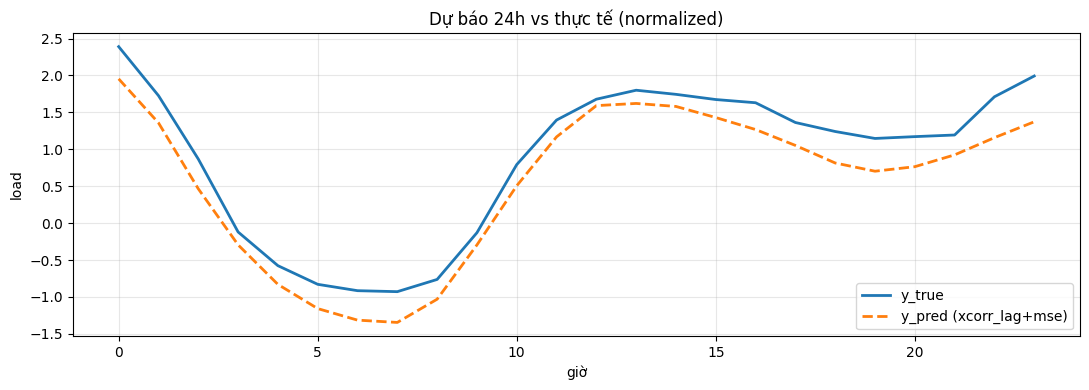

In [29]:
# CELL 15 — Cổng học được (so với prior) + dự báo mẫu
# (a) gates sau huấn luyện của cấu hình xcorr_lag + mse
set_seed(SEEDS[0]); ld = build_loaders(datasets, SEEDS[0])
mdl = TimeXer(profile, idx_map, N_VARS, True, True).to(DEVICE)
_ = train_one(mdl, ld, 'mse', SEEDS[0])
g = mdl.xcorr_exo.gates().detach().cpu().numpy()
print('Cổng g sau train :', dict(zip(profile['names'], np.round(g,3))))
print('Prior R*         :', dict(zip(profile['names'], np.round(profile['R_star'],3))))
print('tau* (giờ)       :', dict(zip(profile['names'], profile['tau_star'].tolist())))

# (b) dự báo vs thực tế 1 mẫu test
mdl.eval()
with torch.no_grad():
    x,y,xm,_ = next(iter(ld['test'])); pr = mdl(x.to(DEVICE), xm.to(DEVICE))
plt.figure(figsize=(11,4))
plt.plot(y[0,-PRED_LEN:,0].numpy(), label='y_true', lw=2)
plt.plot(pr[0,:,0].cpu().numpy(), '--', label='y_pred (xcorr_lag+mse)', lw=2)
plt.title('Dự báo 24h vs thực tế (normalized)'); plt.xlabel('giờ'); plt.ylabel('load')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Diễn giải (điền sau khi chạy)

* So baseline vs xcorr_lag (đa-seed): cơ chế exogenous có giảm MSE/MAE **vượt 1σ** không?
* Cổng học được có **giữ thứ tự** prior (temp cao nhất) hay model ghi đè?
* Tương tác EXO×LOSS: kết hợp có cộng hưởng (tương tác âm) hay hai nhánh trung tính/triệt tiêu?
* Lưu ý phương pháp: kết luận chỉ rút ra **sau** đa-seed; đơn-seed có thể đảo chiều.